In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\Hemalatha\OneDrive\Desktop\Machine Learning\data\titanic.csv")

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
missing_age = df["Age"].isnull().sum()

print("Number of rows where Age is missing:", missing_age)

Number of rows where Age is missing: 177


In [4]:
survived = (df["Survived"] == 1).sum()

print("Number of passengers who survived:", survived)

Number of passengers who survived: 342


In [5]:
dead = (df["Survived"] == 0).sum()

print("Number of people dead:", dead)

Number of people dead: 549


In [7]:
df_clean = df.dropna(subset=["Age"]).copy()

print("Rows before dropping:", len(df))
print("Rows after dropping:", len(df_clean))

Rows before dropping: 891
Rows after dropping: 714


In [8]:
survived_people = df_clean[df_clean["Survived"] == 1]

survived_people[["Name", "Age"]]

,Name,Age
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0
2,"Heikkinen, Miss. Laina",26.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.0
9,"Nasser, Mrs. Nicholas (Adele Achem)",14.0
...,...,...
875,"Najib, Miss. Adele Kiamie ""Jane""",15.0
879,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",56.0
880,"Shelley, Mrs. William (Imanita Parrish Hall)",25.0
887,"Graham, Miss. Margaret Edith",19.0


In [9]:
numeric_df = df_clean.select_dtypes(include="number")

numeric_df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
885,886,0,3,39.0,0,5,29.1250
886,887,0,2,27.0,0,0,13.0000
887,888,1,1,19.0,0,0,30.0000
889,890,1,1,26.0,0,0,30.0000


In [10]:
print(numeric_df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


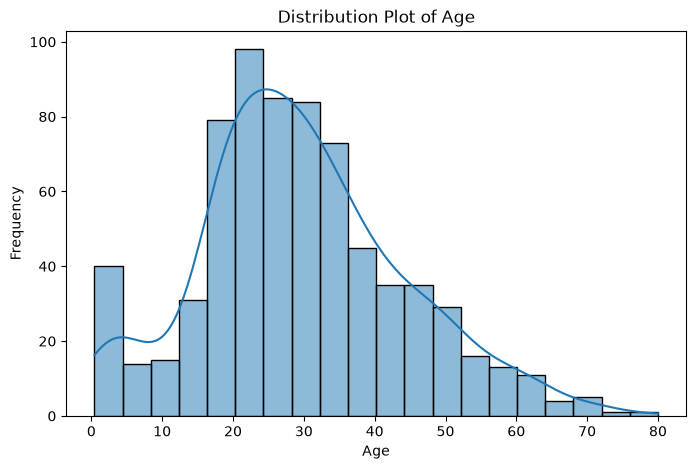

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="Age",
    kde=True
)

plt.title("Distribution Plot of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [12]:
survived_gender = df[df["Survived"] == 1]["Sex"].value_counts()

print("Survived passengers by gender:")
print(survived_gender)

female = survived_gender.get("female", 0)
male = survived_gender.get("male", 0)

print("\nFemale Survivors:", female)
print("Male Survivors:", male)

if female > male:
    print("Proved: More females survived than males.")

Survived passengers by gender:
Sex
female    233
male      109
Name: count, dtype: int64

Female Survivors: 233
Male Survivors: 109
Proved: More females survived than males.


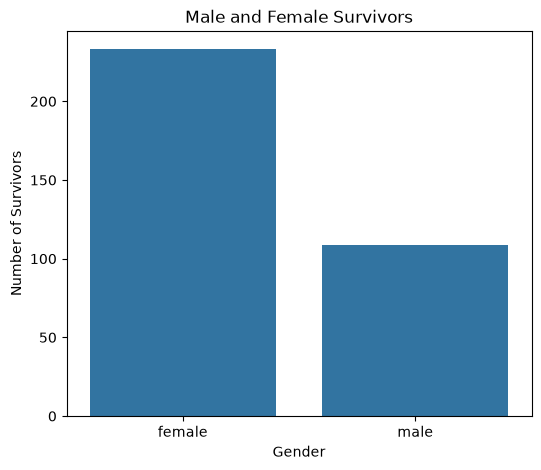

In [13]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df[df["Survived"] == 1],
    x="Sex"
)

plt.title("Male and Female Survivors")
plt.xlabel("Gender")
plt.ylabel("Number of Survivors")

plt.show()

In [14]:
survived_class = (
    df[df["Survived"] == 1]["Pclass"]
    .value_counts()
    .sort_index()
)

print("Survivors by Pclass:")
print(survived_class)

first = survived_class.get(1, 0)
second = survived_class.get(2, 0)
third = survived_class.get(3, 0)

print("\n1st Class Survivors:", first)
print("2nd Class Survivors:", second)
print("3rd Class Survivors:", third)

if first > second and first > third:
    print("Proved: 1st class has more survivors than 2nd and 3rd class individually.")

Survivors by Pclass:
Pclass
1    136
2     87
3    119
Name: count, dtype: int64

1st Class Survivors: 136
2nd Class Survivors: 87
3rd Class Survivors: 119
Proved: 1st class has more survivors than 2nd and 3rd class individually.


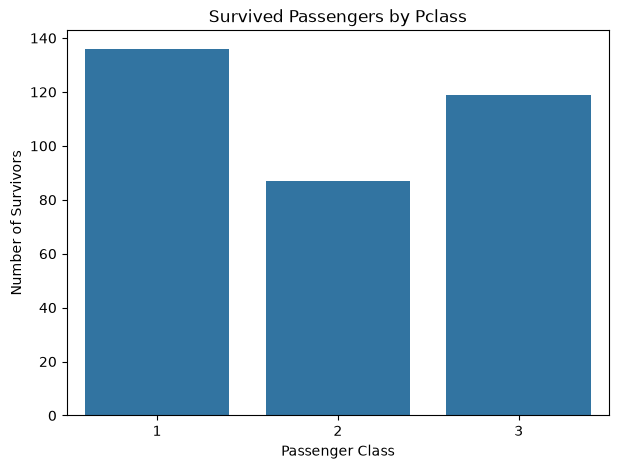

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df[df["Survived"] == 1],
    x="Pclass"
)

plt.title("Survived Passengers by Pclass")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Survivors")

plt.show()